## Stage 2 — Feature Engineering

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

PROJECT_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
CACHE_DIR = PROJECT_ROOT / "data" / "cache"
EDA_DIR = PROJECT_ROOT / "data" / "eda"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from utils import separability_table, print_interpretation, plot_feature_separability, cohens_d
from features import extract_features

FEATURE_COLS = ["mouth_width", "inter_eye_dist", "mouth_eye_ratio",
                "mouth_vertical_lift", "mouth_nose_ratio"]

features_path = CACHE_DIR / "features.pkl"
if features_path.exists():
    df_features = pd.read_pickle(features_path)
    dataset_clean = pd.read_pickle(CACHE_DIR / "dataset_clean.pkl")
    print(f"Loaded cached features ({len(df_features)} rows) from data/cache/features.pkl")
else:
    dataset_clean = pd.read_pickle(CACHE_DIR / "dataset_clean.pkl")
    feature_dicts = [
        extract_features(kps)
        for kps in tqdm(dataset_clean["kps"], desc="Extracting features")
    ]
    df_features = pd.concat(
        [dataset_clean.drop(columns=["kps"]).reset_index(drop=True),
         pd.DataFrame(feature_dicts)],
        axis=1,
    )
    nan_total = int(df_features.isna().sum().sum())
    if nan_total > 0:
        print(f"WARNING: {nan_total} NaN values found:")
        print(df_features[df_features.isna().any(axis=1)])
    assert nan_total == 0, "NaN detected in features"
    df_features.to_pickle(features_path)
    print(f"Built and saved features ({len(df_features)} rows) to data/cache/features.pkl")

print(df_features[["mouth_eye_ratio", "mouth_vertical_lift", "mouth_nose_ratio"]].describe())
print("\nClass balance:")
print(df_features["label"].value_counts().rename({1: "smile", 0: "non_smile"}))

Loaded cached features (3970 rows) from data/cache/features.pkl
       mouth_eye_ratio  mouth_vertical_lift  mouth_nose_ratio
count      3970.000000          3970.000000       3970.000000
mean          0.855477            -1.008607          1.513923
std           0.085800             0.095556          0.274100
min           0.634129            -1.649612          0.765349
25%           0.786689            -1.066054          1.336628
50%           0.852293            -1.002365          1.502746
75%           0.923053            -0.940434          1.661671
max           1.102859            -0.722415          3.324499

Class balance:
label
smile        2151
non_smile    1819
Name: count, dtype: int64


In [2]:
table = separability_table(df_features)
print(table.to_string(index=False))
print_interpretation(table)

            feature  mean_smile  mean_non_smile  pooled_std  cohens_d
    mouth_eye_ratio    0.914852        0.785265    0.056503  2.293442
mouth_vertical_lift   -0.958574       -1.067772    0.078559  1.390015
   mouth_nose_ratio    1.596598        1.416158    0.258965  0.696774
        mouth_width   36.011124       30.824725    8.399295  0.617480
     inter_eye_dist   39.245581       39.387962    9.536390 -0.014930

Interpretation (Cohen's d):
  |d| > 0.8  → large effect
  |d| 0.5–0.8 → medium effect
  |d| 0.2–0.5 → small effect
  |d| < 0.2   → negligible

  mouth_eye_ratio            d = +2.2934  [LARGE]
  mouth_vertical_lift        d = +1.3900  [LARGE]
  mouth_nose_ratio           d = +0.6968  [MEDIUM]
  mouth_width                d = +0.6175  [MEDIUM]
  inter_eye_dist             d = -0.0149  [NEGLIGIBLE]


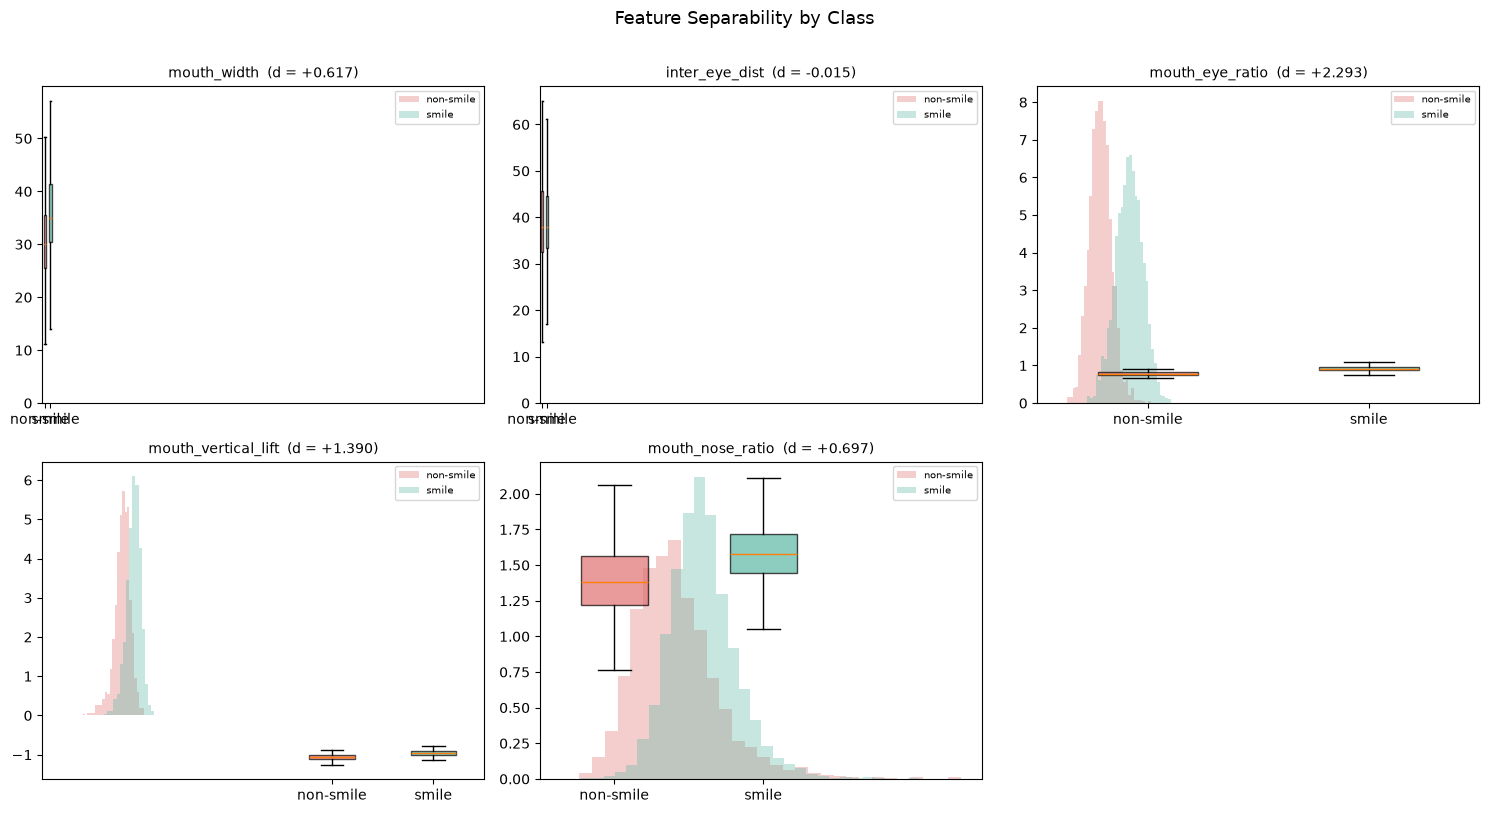

Saved to /mnt/hdd/projects/smile_detection/data/eda/feature_separability.png


In [3]:
plot_feature_separability(
    df_features,
    feature_cols=FEATURE_COLS,
    save_path=str(EDA_DIR / "feature_separability.png"),
)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Expected: normalization must NOT change Cohen's d — linear scaling shifts/scales
# each class equally, so separability is identical, only the units change.

# 1. Stratified 80/20 split (reuse previous split if already defined)
if "df_train" not in globals() or len(df_train) == 0:
    df_train, df_test = train_test_split(
        df_features, test_size=0.2, stratify=df_features["label"], random_state=42
    )
print(f"df_train: {len(df_train)} rows | df_test: {len(df_test)} rows")
print("\nTrain class ratio:")
print(df_train["label"].value_counts(normalize=True).round(4).rename({1: "smile", 0: "non_smile"}))
print("\nTest class ratio:")
print(df_test["label"].value_counts(normalize=True).round(4).rename({1: "smile", 0: "non_smile"}))

# 2. Fit scalers on TRAIN only, transform train + test
scaler_std = StandardScaler().fit(df_train[FEATURE_COLS])
scaler_minmax = MinMaxScaler().fit(df_train[FEATURE_COLS])

# Fight index-misalignment: pass df_train.index so labels stay paired with
# the right scaled rows when concatenated for Cohen's d below.
train_std = pd.DataFrame(scaler_std.transform(df_train[FEATURE_COLS]),
                         columns=FEATURE_COLS, index=df_train.index)
train_minmax = pd.DataFrame(scaler_minmax.transform(df_train[FEATURE_COLS]),
                          columns=FEATURE_COLS, index=df_train.index)

# 3+4. Cohen's d on training portion: original vs scaled
rows = []
for col in FEATURE_COLS:
    d_orig = cohens_d(df_train, col)
    d_std = cohens_d(pd.concat([train_std, df_train[["label"]]], axis=1), col)
    d_mm = cohens_d(pd.concat([train_minmax, df_train[["label"]]], axis=1), col)
    rows.append({
        "feature": col,
        "original_d": d_orig,
        "standard_d": d_std,
        "minmax_d": d_mm,
    })

comp = pd.DataFrame(rows)
print("\n=== Cohen's d: original vs scaled (train only) ===")
print(comp.to_string(index=False))

# Assert scaling invariance (allowing tiny float rounding)
max_std_dev = (comp["original_d"] - comp["standard_d"]).abs().max()
max_mm_dev = (comp["original_d"] - comp["minmax_d"]).abs().max()
print(f"\nMax |delta| StandardScaler: {max_std_dev:.2e}")
print(f"Max |delta| MinMaxScaler:    {max_mm_dev:.2e}")
assert max_std_dev < 1e-9, "StandardScaler changed Cohen's d — data leak?"
assert max_mm_dev < 1e-9, "MinMaxScaler changed Cohen's d — data leak?"
print("Cohens d unchanged by scaling — assertion passed.")

df_train: 3176 rows | df_test: 794 rows

Train class ratio:
label
smile        0.5419
non_smile    0.4581
Name: proportion, dtype: float64

Test class ratio:
label
smile        0.5416
non_smile    0.4584
Name: proportion, dtype: float64

=== Cohen's d: original vs scaled (train only) ===
            feature  original_d  standard_d  minmax_d
        mouth_width    0.630380    0.630380  0.630380
     inter_eye_dist   -0.007013   -0.007013 -0.007013
    mouth_eye_ratio    2.309089    2.309089  2.309089
mouth_vertical_lift    1.377900    1.377900  1.377900
   mouth_nose_ratio    0.703278    0.703278  0.703278

Max |delta| StandardScaler: 3.11e-15
Max |delta| MinMaxScaler:    2.66e-15
Cohens d unchanged by scaling — assertion passed.


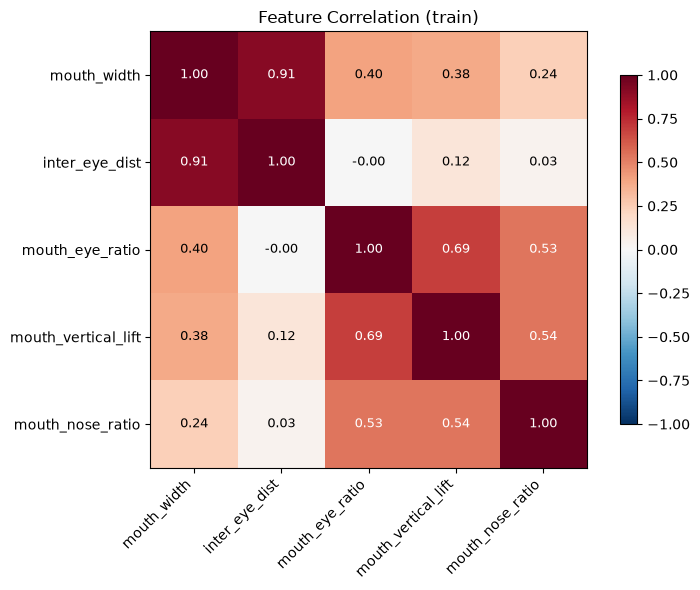

Saved to data/eda/feature_correlation.png

Feature pairs with |corr| > 0.9:
('mouth_width', 'inter_eye_dist', np.float64(0.9106291958280877))

Mouth_eye_ratio correlations:
mouth_width            0.400601
inter_eye_dist        -0.002443
mouth_vertical_lift    0.690125
mouth_nose_ratio       0.532638

=== FINAL MODELING FEATURE LIST ===
  mouth_eye_ratio            |d|=2.3091
  mouth_vertical_lift        |d|=1.3779
  mouth_nose_ratio           |d|=0.7033
  mouth_width                |d|=0.6304
Dropped: ['inter_eye_dist']

Raw ranges in df_train:
  mouth_eye_ratio           (0.6341, 1.1029)
  mouth_vertical_lift       (-1.6496, -0.7224)
  mouth_nose_ratio          (0.7653, 3.3245)
  mouth_width               (7.0038, 77.0208)

Paste-ready list:
FEATURES_FINAL = ['mouth_eye_ratio', 'mouth_vertical_lift', 'mouth_nose_ratio', 'mouth_width']


In [5]:
# Expected: mouth_width ~ inter_eye_dist (both scale with face size) will correlate
# > 0.9; mouth_eye_ratio should correlate weakly with both since it cancels face size.

corr = df_train[FEATURE_COLS].corr()

# 1. Heatmap with diverging colormap centered at 0
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        cval = corr.iloc[i, j]
        ax.text(j, i, f"{cval:.2f}", ha="center", va="center",
                color="white" if abs(cval) > 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation (train)")
plt.tight_layout()
fig.savefig(EDA_DIR / "feature_correlation.png", dpi=150)
plt.show()
print(f"Saved to data/eda/feature_correlation.png")

# 2. Pairs with |correlation| > 0.9
high_pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        cval = corr.iloc[i, j]
        if abs(cval) > 0.9:
            high_pairs.append((corr.columns[i], corr.columns[j], cval))
print("\nFeature pairs with |corr| > 0.9:")
for p in high_pairs:
    print(p)
print("\nMouth_eye_ratio correlations:")
print(corr["mouth_eye_ratio"].drop("mouth_eye_ratio").to_string())

# 3. Cohen's d lookup (train, from the scaling-comparison table)
d_by_feature = comp.set_index("feature")["original_d"].to_dict()

to_drop = set()
for a, b, _ in high_pairs:
    keep = a if abs(d_by_feature.get(a, 0.0)) >= abs(d_by_feature.get(b, 0.0)) else b
    to_drop.add(b if keep == a else a)

# 4. Survivors in order of descending |Cohen's d|
FEATURES_FINAL = [
    f for f in sorted(FEATURE_COLS, key=lambda x: -abs(d_by_feature.get(x, 0.0)))
    if f not in to_drop
]

print("\n=== FINAL MODELING FEATURE LIST ===")
for f in FEATURES_FINAL:
    print(f"  {f:25s}  |d|={abs(d_by_feature.get(f, 0.0)):.4f}")
print(f"Dropped: {sorted(to_drop)}")

# 5. Raw unscaled ranges in df_train (to sanity-check scaling need)
print("\nRaw ranges in df_train:")
for f in FEATURES_FINAL:
    print(f"  {f:25s} ({df_train[f].min():.4f}, {df_train[f].max():.4f})")

print("\nPaste-ready list:")
print("FEATURES_FINAL = " + repr(FEATURES_FINAL))